# 03. MLP をゼロから作る — Linear・活性化・損失・SGD

## この章で分かること

- **Linear 層**(アフィン変換)の forward と backward を行列で実装する
- ReLU / sigmoid / tanh / softmax と、MSE / クロスエントロピー損失
- **ミニバッチ SGD** と学習ループ
- 学習中に決定境界・損失曲線・隠れ表現がどう動くかを観察する

02 章のスカラー逆伝播を、**テンソル(行列)レベル** に引き上げて、
moons / circles / spiral を実際に分類できる MLP を一から組み立てます。

```{admonition} 核心 — ひとことで
:class: tip
**各層は「forward（値を作る）／backward（勾配を配る）」の対であり、それを繋ぐだけでネットになる。**
Linear の backward は形（shape）が合うように転置を決めるだけ：$\partial L/\partial W = X^\top G,\ \ \partial L/\partial X = G W^\top$。
softmax＋クロスエントロピーの勾配は $(p-\mathrm{onehot})/N$。これらをミニバッチ SGD で回せば「学習」になる。
```

## 1. Big Picture — 層 = forward と backward の対

ニューラルネットは層の積み重ねです。各層は 2 つの仕事を持ちます。

- **forward**: 入力 $x$ を受けて出力 $y$ を返す
- **backward**: 上流からの勾配 $\partial L / \partial y$ を受けて、
  下流へ渡す勾配 $\partial L / \partial x$ と、自分のパラメータの勾配を計算する

この「forward / backward の対」を層ごとに作って繋げば、
ネット全体の逆伝播は **層を逆順にたどるだけ** になります(02 章の連鎖律のテンソル版)。

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from nn_textbook import datasets, metrics, plotting
from nn_textbook.training import set_seed, train_numpy_mlp

set_seed(0)
np.set_printoptions(precision=3, suppress=True)

## 2. Definition — Linear 層の数式

Linear 層はアフィン変換です。バッチ $X \in \mathbb{R}^{N \times d_\text{in}}$ に対し:

$$
Y = X W + b, \qquad W \in \mathbb{R}^{d_\text{in} \times d_\text{out}},\; b \in \mathbb{R}^{d_\text{out}}
$$

backward は連鎖律から(上流勾配を $G = \partial L / \partial Y \in \mathbb{R}^{N \times d_\text{out}}$ として):

$$
\frac{\partial L}{\partial W} = X^\top G, \qquad
\frac{\partial L}{\partial b} = \sum_n G_n, \qquad
\frac{\partial L}{\partial X} = G W^\top
$$

形(shape)が合うように転置が決まる、と覚えると忘れません。
`nn_textbook.layers.Linear` がまさにこれを実装しています。読んでみましょう。

In [2]:
# Read the actual from-scratch Linear layer used throughout this notebook.
import inspect

from nn_textbook.layers import Linear

print(inspect.getsource(Linear))

class Linear:
    """Affine layer: y = x W + b.   x:(N, in)  W:(in, out)  b:(out,)  y:(N, out)."""

    def __init__(self, n_in: int, n_out: int, seed: int = 0, init: str = "he"):
        rng = np.random.default_rng(seed)
        if init == "he":
            scale = np.sqrt(2.0 / n_in)
        elif init == "xavier":
            scale = np.sqrt(1.0 / n_in)
        else:
            scale = 0.01
        self.W = (rng.standard_normal((n_in, n_out)) * scale).astype(np.float64)
        self.b = np.zeros(n_out, dtype=np.float64)
        self.x = None
        self.dW = None
        self.db = None

    def forward(self, x):
        self.x = x
        return x @ self.W + self.b

    def backward(self, grad):
        # grad: (N, out). Chain rule through an affine map.
        self.dW = self.x.T @ grad  # (in, out)
        self.db = grad.sum(axis=0)  # (out,)
        return grad @ self.W.T  # (N, in) -> passed upstream

    def params_and_grads(self):
        return [(self.W, self.dW), (self.b, s

shape の確認は実装の生命線です。forward / backward で形を表示してみます。

In [3]:
# Verify the shapes of a Linear layer's forward and backward.
lin = Linear(3, 4, seed=0)
X = np.random.default_rng(0).standard_normal((5, 3))   # batch N=5, in=3
Y = lin.forward(X)
G = np.ones((5, 4))                                     # pretend upstream grad
dX = lin.backward(G)
print(f"X: {X.shape}  W: {lin.W.shape}  b: {lin.b.shape}  ->  Y: {Y.shape}")
print(f"upstream G: {G.shape}  ->  dX: {dX.shape}  dW: {lin.dW.shape}  db: {lin.db.shape}")

X: (5, 3)  W: (3, 4)  b: (4,)  ->  Y: (5, 4)
upstream G: (5, 4)  ->  dX: (5, 3)  dW: (3, 4)  db: (4,)


## 3. Definition — 活性化と損失

**活性化**(要素ごと、backward は要素ごとの微分を掛ける):

$$
\mathrm{ReLU}(x) = \max(0, x), \quad
\sigma(x) = \frac{1}{1+e^{-x}}, \quad
\tanh(x)
$$

**softmax + クロスエントロピー損失**(分類):

$$
p_i = \frac{e^{z_i}}{\sum_j e^{z_j}}, \qquad
L = -\frac{1}{N}\sum_n \log p_{n, y_n}
$$

このペアの backward は驚くほど簡単で、**$\partial L / \partial z = (p - \text{onehot}(y)) / N$**。
softmax と log の微分が打ち消し合うためです(導出は Advanced Notes)。

**MSE 損失**(回帰): $L = \frac{1}{NM}\sum (\hat{y} - y)^2$。

In [4]:
# Activations and losses, all from scratch. Check CE gradient against the formula.
from nn_textbook.layers import ReLU, Sigmoid, Tanh, CrossEntropyLoss, softmax

logits = np.array([[2.0, 1.0, 0.1],
                   [0.5, 2.5, 0.3]])
targets = np.array([0, 1])
ce = CrossEntropyLoss()
loss = ce.forward(logits, targets)
grad = ce.backward()
print(f"cross entropy loss = {loss:.4f}")
print("probabilities:\n", softmax(logits))
print("grad wrt logits (= (p - onehot)/N):\n", grad)

cross entropy loss = 0.3185
probabilities:
 [[0.659 0.242 0.099]
 [0.109 0.802 0.089]]
grad wrt logits (= (p - onehot)/N):
 [[-0.17   0.121  0.049]
 [ 0.054 -0.099  0.044]]


## 4. Computation — MLP を組み立てる

層を並べて MLP にします。`nn_textbook.models.MLP` は
`Linear -> activation -> ... -> Linear` を構築し、loss / backward / SGD 更新を提供します。
中身はこれまで見た層の合成にすぎません。

In [5]:
# The MLP just chains the layers we already understand. Read its forward/backward.
from nn_textbook.models import MLP

print(inspect.getsource(MLP.forward))
print(inspect.getsource(MLP.backward))

    def forward(self, x):
        for layer in self.layers:
            x = layer.forward(x)
        return x

    def backward(self):
        grad = self.loss_fn.backward()
        for layer in reversed(self.layers):
            grad = layer.backward(grad)
        return grad



## 5. ミニバッチ SGD と学習ループ

**確率的勾配降下法 (SGD)**: データ全部ではなく、毎回ランダムな小さな塊(ミニバッチ)で
勾配を計算して更新します。

$$
\theta \leftarrow \theta - \eta\, \nabla_\theta L_{\text{batch}}
$$

- ノイズが入る分、計算が軽く、局所解から抜けやすい
- バッチサイズ $B$ と学習率 $\eta$ が主なハイパーパラメータ

学習ループ本体(`train_numpy_mlp`)も読んでおきます。

In [6]:
# The training loop: shuffle, take mini-batches, forward, backward, SGD update.
print(inspect.getsource(train_numpy_mlp))

def train_numpy_mlp(
    model,
    X,
    y,
    lr: float = 0.1,
    epochs: int = 200,
    batch_size: int = 32,
    X_val=None,
    y_val=None,
    seed: int = 0,
    record_every: int = 1,
):
    """Mini-batch SGD for the NumPy ``MLP``.

    Returns a history dict with 'loss' (and 'val_acc' when validation is given).
    """
    rng = np.random.default_rng(seed)
    n = len(X)
    history = {"loss": [], "val_acc": [], "epoch": []}
    for epoch in range(epochs):
        perm = rng.permutation(n)
        epoch_loss = 0.0
        for start in range(0, n, batch_size):
            idx = perm[start : start + batch_size]
            loss = model.loss(X[idx], y[idx])
            model.backward()
            for param, grad in model.params_and_grads():
                param -= lr * grad  # in-place SGD step
            epoch_loss += loss * len(idx)
        if epoch % record_every == 0 or epoch == epochs - 1:
            history["epoch"].append(epoch)
            history["loss"].append(epo

## 6. moons を分類する

実際に学習させます。損失曲線と決定境界を見ます。

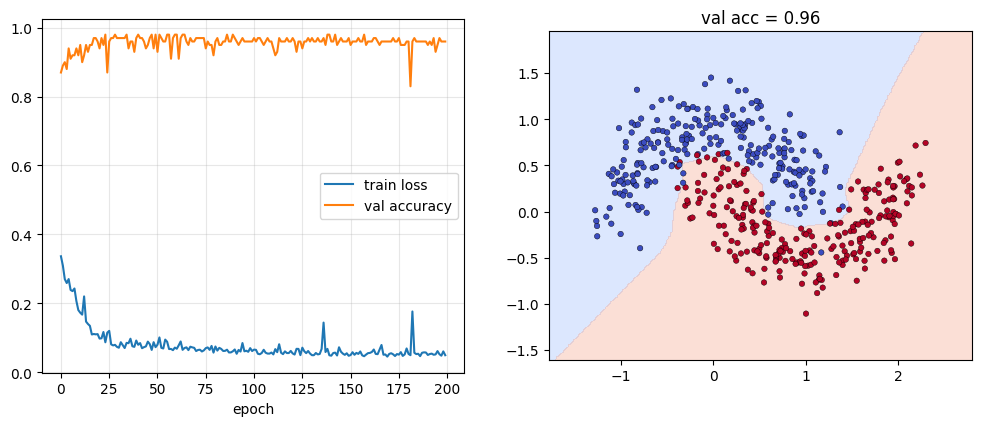

In [7]:
# Train on moons and look at the loss curve + decision boundary.
Xm, ym = datasets.make_moons_dataset(n=500, noise=0.2, seed=0)
Xtr, ytr, Xval, yval = datasets.train_val_split(Xm, ym, val_frac=0.2, seed=0)

model = MLP([2, 32, 32, 2], activation="relu", seed=0)
hist = train_numpy_mlp(model, Xtr, ytr, lr=0.3, epochs=200, batch_size=32,
                       X_val=Xval, y_val=yval, seed=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
axes[0].plot(hist["epoch"], hist["loss"], label="train loss")
axes[0].plot(hist["epoch"], hist["val_acc"], label="val accuracy")
axes[0].set_xlabel("epoch"); axes[0].grid(alpha=0.3); axes[0].legend()
plotting.plot_decision_boundary(model.predict, Xm, ym, ax=axes[1],
                                title=f"val acc = {hist['val_acc'][-1]:.2f}")
plt.show()

## 7. Visualization — 学習中に境界が育つ

決定境界が学習とともにどう形成されるかを、エポックを止めながら見ます。
最初はほぼ直線、徐々に moons に沿って曲がっていきます。

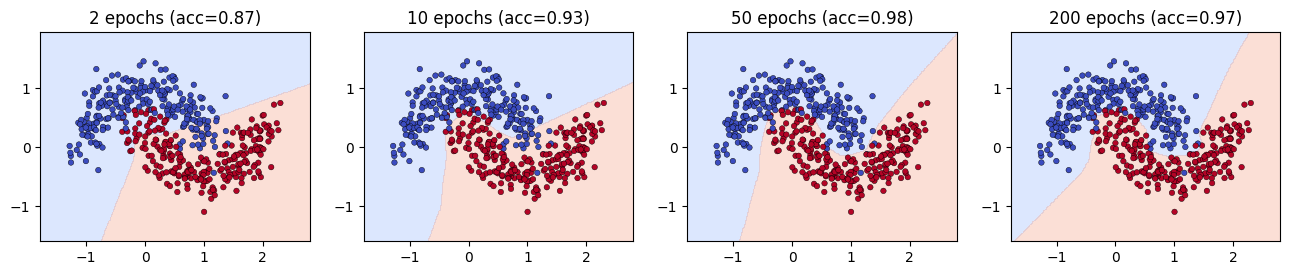

In [8]:
# Snapshots of the decision boundary at increasing training budgets.
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, ep in zip(axes, [2, 10, 50, 200], strict=True):
    m = MLP([2, 32, 32, 2], activation="relu", seed=0)
    train_numpy_mlp(m, Xtr, ytr, lr=0.3, epochs=ep, batch_size=32, seed=0)
    acc = metrics.accuracy(m.predict(Xm), ym)
    plotting.plot_decision_boundary(m.predict, Xm, ym, ax=ax, title=f"{ep} epochs (acc={acc:.2f})")
plt.show()

### ▶ 触って確かめる — 学習中に境界が育つ（HTML でも動く）

上の 4 枚を、スライダーで連続的に。エポックを進めると、ミニバッチ SGD が決定境界を
直線から moons の形へ育てていきます（上の JupyterLab 限定ウィジェットと違い、これは**静的 HTML でも動作**）。

In [9]:
import plotly.io as pio

pio.renderers.default = "plotly_mimetype+notebook_connected"
fig = plotting.plotly_decision_boundary(Xm, ym, title="学習が進むと境界が moons に沿う")
fig.show()

### 確率の勾配場 — 境界の「向き」を見る

決定境界の周りで、モデルの出力(クラス 1 の確率)が入力のどの方向に増えるかを
**勾配場**(ベクトル場)として描きます。矢印はクラス 1 領域の方向を指し、
境界付近で最も大きくなります。「境界 = 確率が急変する場所」が見て取れます。

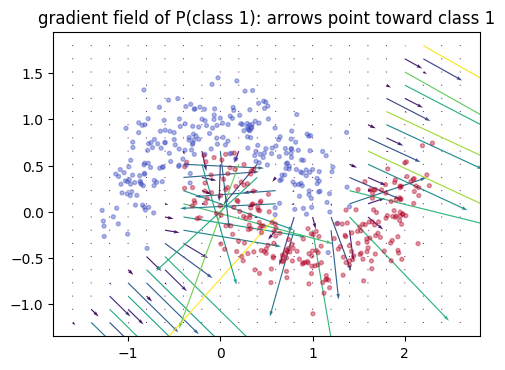

In [10]:
# Gradient field of P(class 1) over the input plane (numerical gradient).
from nn_textbook.layers import softmax

def prob1(pts):
    return softmax(model.forward(pts.astype(np.float32)))[:, 1]

def prob1_grad(pts, eps=1e-2):
    g = np.zeros_like(pts, dtype=float)
    for d in range(2):
        e = np.zeros(2); e[d] = eps
        g[:, d] = (prob1(pts + e) - prob1(pts - e)) / (2 * eps)
    return g

ax = plotting.plot_gradient_field(prob1_grad, x_range=(-1.6, 2.6), y_range=(-1.2, 1.8), n=22)
ax.scatter(Xm[:, 0], Xm[:, 1], c=ym, cmap="coolwarm", s=8, alpha=0.4)
ax.set_title("gradient field of P(class 1): arrows point toward class 1")
plt.show()

### インタラクティブ: 学習過程をスクラブする(JupyterLab のみ)

スライダーで学習ステップ数を動かし、決定境界が育つ過程を行き来できるデモです。
同じ seed から再学習するため、スライダーをどの順に動かしても再現的です。

In [11]:
# Interactive (JupyterLab only): scrub through training steps.
from nn_textbook.widgets import decision_boundary_trainer

scrub_model = MLP([2, 32, 32, 2], activation="relu", seed=0)

def step_fn(m, n_steps):
    # Retrain from scratch for n_steps epochs (deterministic per slider value).
    m.__init__([2, 32, 32, 2], activation="relu", seed=0)
    if n_steps > 0:
        train_numpy_mlp(m, Xtr, ytr, lr=0.3, epochs=n_steps, batch_size=32, seed=0)

decision_boundary_trainer(scrub_model, Xm, ym, step_fn, max_steps=200, stride=10)

interactive(children=(IntSlider(value=0, description='steps', max=200, step=10), Output()), _dom_classes=('wid…

<function nn_textbook.widgets.decision_boundary_trainer.<locals>.draw(steps)>

### インタラクティブ: 学習率の効果(JupyterLab のみ)

学習率を変えて moons を学習し、決定境界の違いを見るデモです。
小さすぎると学習が進まず、大きすぎると不安定になります。

In [12]:
# Interactive (JupyterLab only): slide the learning rate, retrain, redraw.
from nn_textbook.widgets import learning_rate_explorer

def fresh_model():
    return MLP([2, 32, 32, 2], activation="relu", seed=0)

def quick_train(model, X, y, lr):
    train_numpy_mlp(model, X, y, lr=lr, epochs=150, batch_size=32, seed=0)

learning_rate_explorer(fresh_model, Xm, ym, quick_train)

interactive(children=(FloatSlider(value=-1.0, description='log10 lr', max=0.5, min=-3.0, step=0.25), Output())…

<function nn_textbook.widgets.learning_rate_explorer.<locals>.draw(log_lr)>

学習率を静的にも比較しておきます(HTML でも見えるように)。

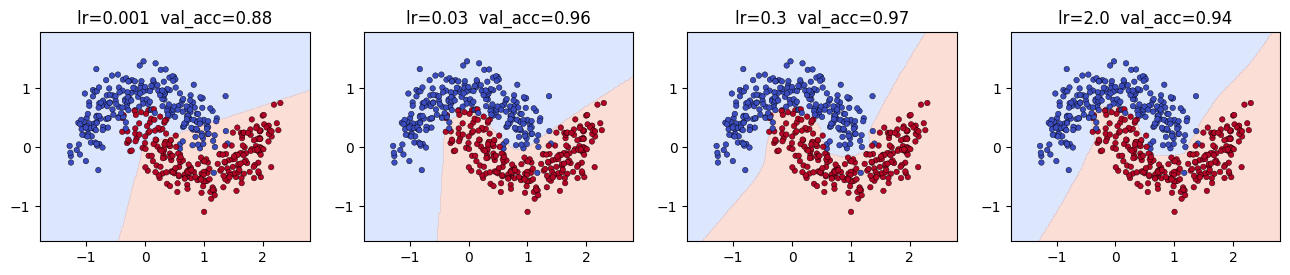

In [13]:
# Static learning-rate sweep so the exported HTML shows the effect too.
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, lr in zip(axes, [0.001, 0.03, 0.3, 2.0], strict=True):
    m = MLP([2, 32, 32, 2], activation="relu", seed=0)
    h = train_numpy_mlp(m, Xtr, ytr, lr=lr, epochs=150, batch_size=32,
                        X_val=Xval, y_val=yval, seed=0)
    plotting.plot_decision_boundary(m.predict, Xm, ym, ax=ax,
                                    title=f"lr={lr}  val_acc={h['val_acc'][-1]:.2f}")
plt.show()

## 8. 幅と深さの効果

隠れ層の幅・深さを変えて、表現力(境界の複雑さ)がどう変わるかを spiral で見ます。
spiral は 3 クラスでねじれており、十分な容量が必要です。

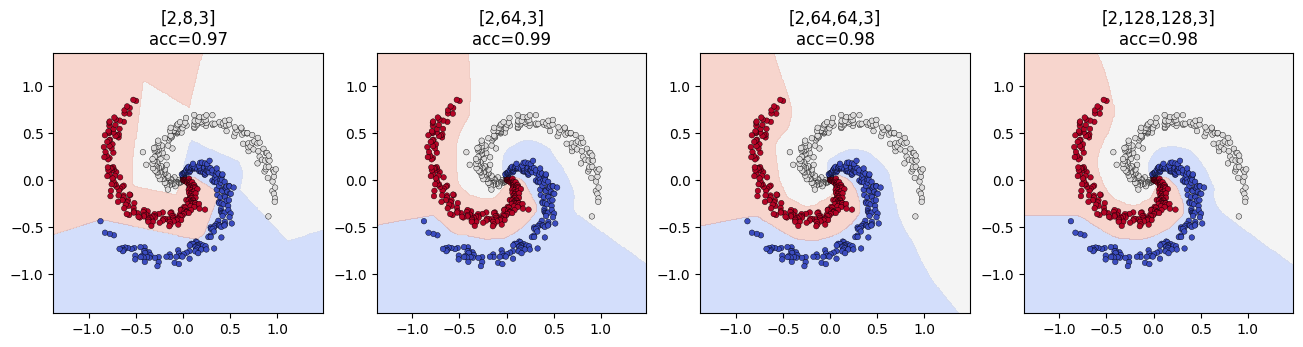

In [14]:
# Capacity sweep on the 3-class spiral.
Xs, ys = datasets.make_spiral_dataset(n_per_class=200, n_classes=3, noise=0.2, seed=0)

configs = [("[2,8,3]", [2, 8, 3]),
           ("[2,64,3]", [2, 64, 3]),
           ("[2,64,64,3]", [2, 64, 64, 3]),
           ("[2,128,128,3]", [2, 128, 128, 3])]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (name, sizes) in zip(axes, configs, strict=True):
    m = MLP(sizes, activation="relu", seed=0)
    train_numpy_mlp(m, Xs, ys, lr=0.5, epochs=300, batch_size=64, seed=0)
    acc = metrics.accuracy(m.predict(Xs), ys)
    plotting.plot_decision_boundary(m.predict, Xs, ys, ax=ax, title=f"{name}\nacc={acc:.2f}")
plt.show()

小さなネットは spiral の腕を追えず、容量を増やすと境界がねじれに沿います。
ただし大きくしすぎるとノイズまで覚える(過学習) — そのコントロールが 04 章のテーマです。

## 9. Application — これがそのまま実用ネットの骨格

ここで作った部品(Linear・活性化・softmax・クロスエントロピー・SGD・ミニバッチ学習)は、
規模こそ違え **すべての実用ネットに共通の骨格** です。
PyTorch の `nn.Linear` / `nn.ReLU` / `nn.CrossEntropyLoss` / `optim.SGD` は、
本章の NumPy 実装を最適化・GPU 化したものにすぎません。

次章からは PyTorch を使いますが、「中で何が起きているか」はもう分かっているはずです。

```{admonition} 実社会では
:class: important
ここで自作した部品＝実用フレームワークの中身そのものです。

- `nn.Linear` / `nn.ReLU` / `nn.CrossEntropyLoss` / `optim.SGD` は本章の NumPy 実装の最適化・GPU 版。
- 「層＝行列積」だから GPU で大規模並列化でき、深層学習が現実になった。
- 学習率・バッチサイズの調整（小さすぎ→進まない、大きすぎ→発散）は、どんな実モデルでも最初に効くつまみ。
```

In [15]:
# Sanity check: our from-scratch MLP and PyTorch reach similar accuracy on moons.
import torch

from nn_textbook.models import make_torch_mlp

torch_net = make_torch_mlp([2, 32, 32, 2], activation="relu")
opt = torch.optim.SGD(torch_net.parameters(), lr=0.3)
loss_fn = torch.nn.CrossEntropyLoss()
Xt = torch.tensor(Xtr); yt = torch.tensor(ytr)
for _ in range(200):
    opt.zero_grad()
    loss_fn(torch_net(Xt), yt).backward()
    opt.step()
torch_acc = (torch_net(torch.tensor(Xm)).argmax(1).numpy() == ym).mean()
print(f"from-scratch NumPy MLP acc: {metrics.accuracy(model.predict(Xm), ym):.3f}")
print(f"PyTorch MLP acc           : {torch_acc:.3f}")

from-scratch NumPy MLP acc: 0.974
PyTorch MLP acc           : 0.964


## 10. まとめ

- 層は **forward / backward の対**。Linear の backward は $X^\top G$, $G W^\top$(shape が合うように転置)。
- softmax + クロスエントロピーの勾配は $(p - \text{onehot})/N$ — 実装上は両者を融合する。
- **ミニバッチ SGD**: 学習率とバッチサイズが主要ハイパーパラメータ。学習率が大きすぎると発散。
- 幅・深さが境界の複雑さを決める。容量不足は underfit、過剰は overfit の芽(04 章)。
- ここで作った NumPy 部品が、そのまま PyTorch の `nn.Linear` / `CrossEntropyLoss` / `SGD` の中身。

## 11. Exercises

1. `Linear.backward` の 3 つの式($dW, db, dX$)の shape を、紙の上で確認せよ。
2. 活性化を relu / tanh / sigmoid で切り替え、spiral での収束の速さと最終精度を比べよ。
3. バッチサイズを 8 / 32 / 256 と変え、損失曲線の滑らかさと 1 エポックの速さを比較せよ。
4. circles で隠れ幅を 2 にした MLP の **隠れ表現**(`hidden_representation`)を散布図にし、
   線形分離可能になっているか確認せよ(01 章の再現)。
5. 学習率を上げすぎると損失が発散することを、損失曲線で示せ。
6. (発展)`MLP` に L2 正則化(重みに $\lambda \|W\|^2$ の罰金)を加え、
   spiral の過学習が緩むか実験せよ。

## 12. Advanced Notes

**softmax+クロスエントロピーの勾配が $(p - \text{onehot})/N$ になる導出。**
$L = -\log p_y$, $p_i = e^{z_i}/\sum_j e^{z_j}$ とする。
$\partial L/\partial z_i = -\partial \log p_y/\partial z_i$。
$\partial \log p_y/\partial z_i = \mathbb{1}[i=y] - p_i$ を使うと
$\partial L/\partial z_i = p_i - \mathbb{1}[i=y]$。バッチ平均で $1/N$ が付きます。
softmax と log を別々に逆伝播すると数値的に不安定になりがちなので、
実装では両者を融合した式を直接使います(`CrossEntropyLoss`)。

**重み初期化はなぜ効くか(予告)。** `Linear` は既定で He 初期化
($\mathrm{std} = \sqrt{2/d_\text{in}}$)を使っています。これは ReLU ネットで
各層の活性の分散を保ち、勾配消失/爆発を防ぐためです。詳細は 04 章。

**SGD の確率性の利点。** フルバッチ勾配降下より、ミニバッチの勾配ノイズは
鋭い極小(汎化の悪い解)を避け、平らな極小に落ちやすいと経験的に知られています。
バッチサイズと学習率はしばしば一緒にスケールさせます(線形スケーリング則)。

**ベクトル化の重要性。** forward/backward を for ループでなく行列積($X W$, $X^\top G$)で
書くのは、可読性だけでなく BLAS による高速化のためです。
「層 = 行列演算」という見方が、GPU が深層学習を加速できる理由そのものです。

## ネットがクラスを解きほぐす(インタラクティブ)

入力平面では線形分離できない同心円データを、学習が進むにつれてネットが出力空間で線形分離可能な 2 つの塊へと変えていく様子。

In [16]:
import plotly.io as pio
from nn_textbook import plotting as viz

pio.renderers.default = "plotly_mimetype+notebook_connected"
fig = viz.plotly_hidden_unfolding()
fig.show()